In [1]:
#Step 0 load library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

#Step 1 Understand data structure
df=pd.read_csv(r"C:\Users\rafaa\Downloads\framingham.csv")
print(df.info())
print(df.describe())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB
None
        

In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
#Step 3 explare data
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


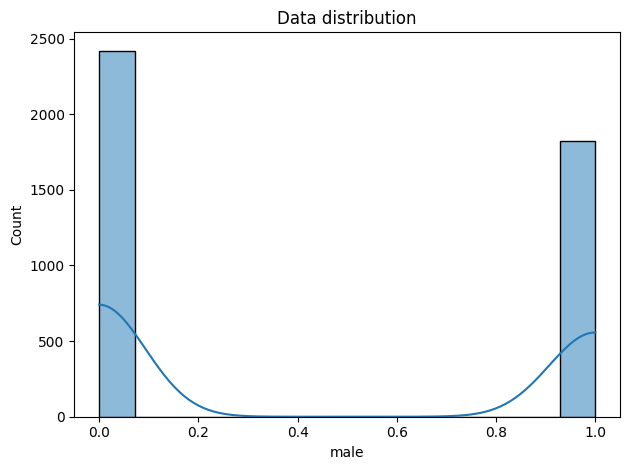

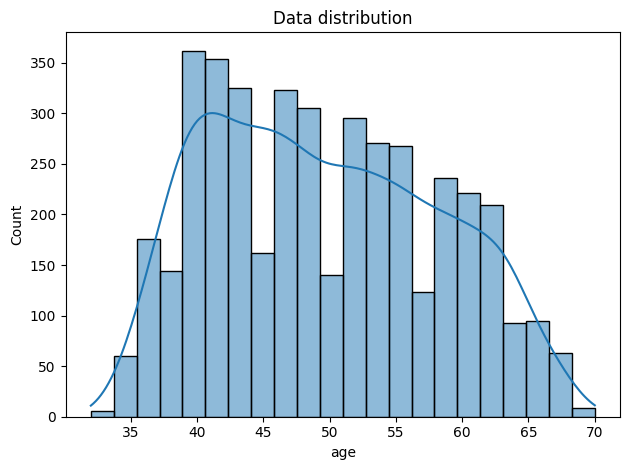

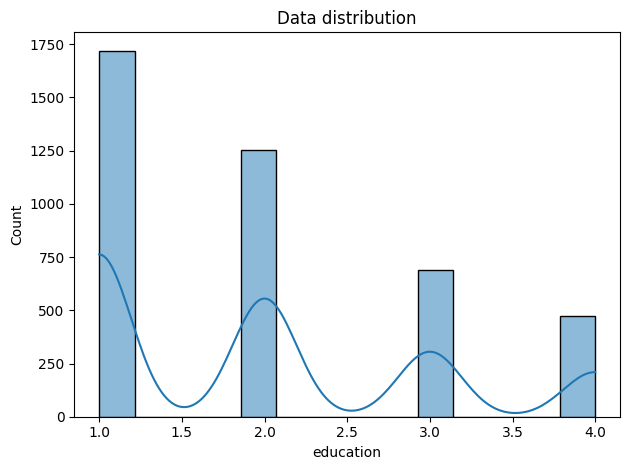

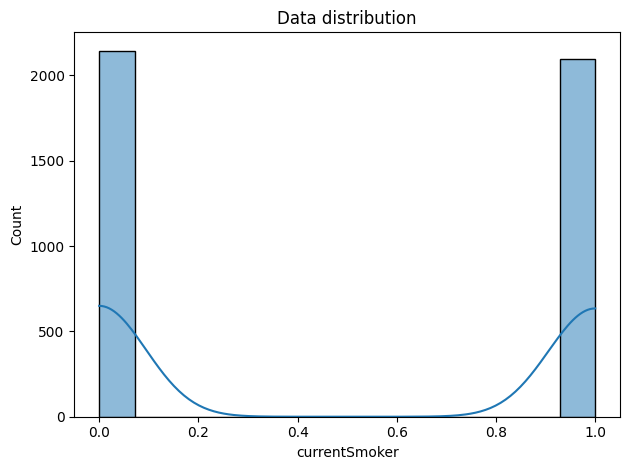

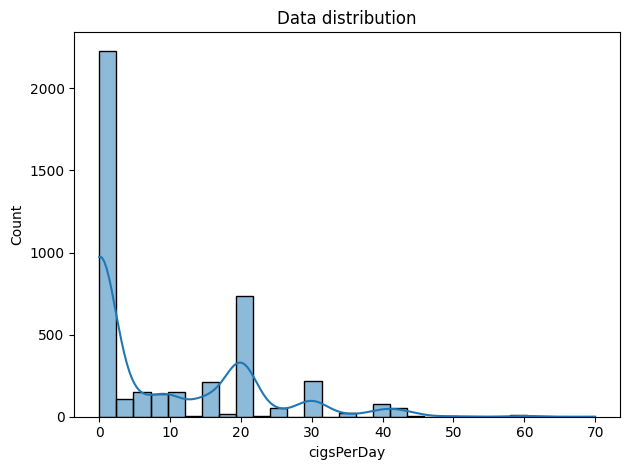

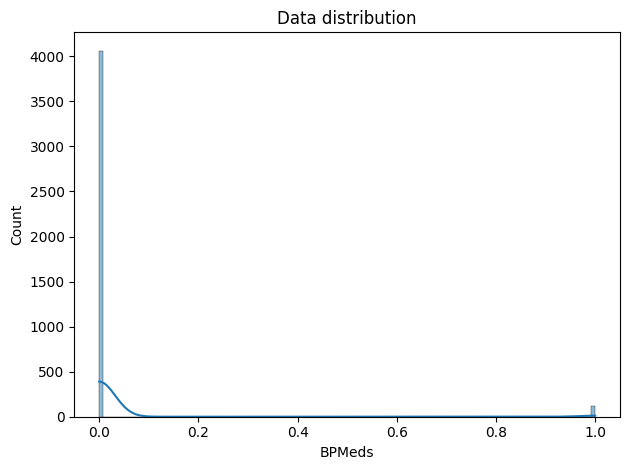

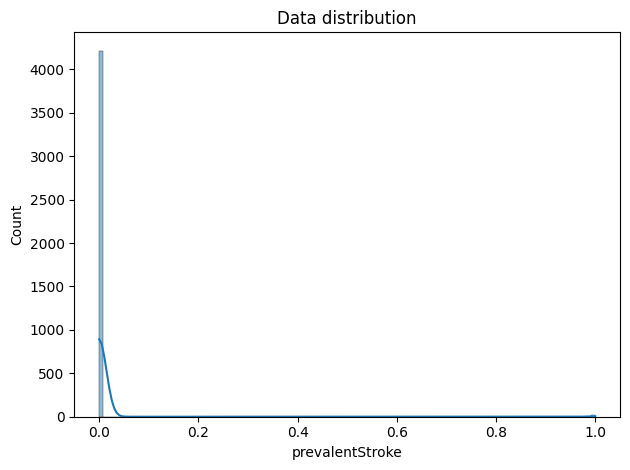

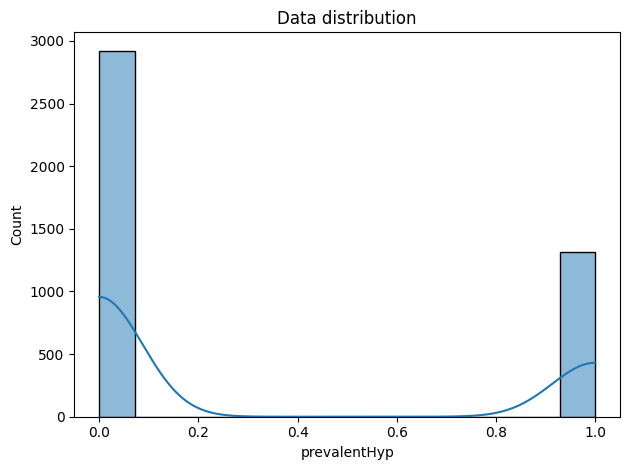

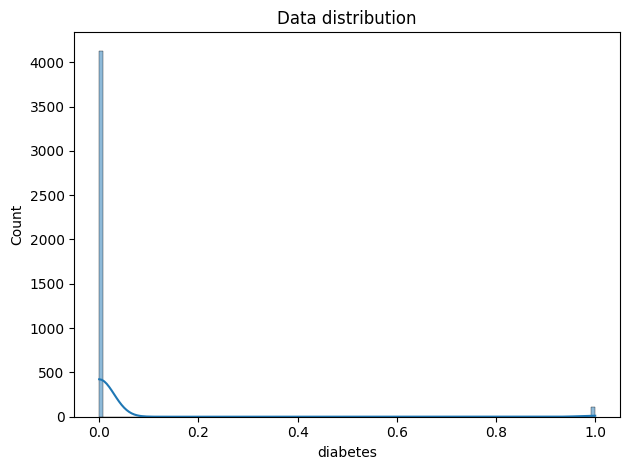

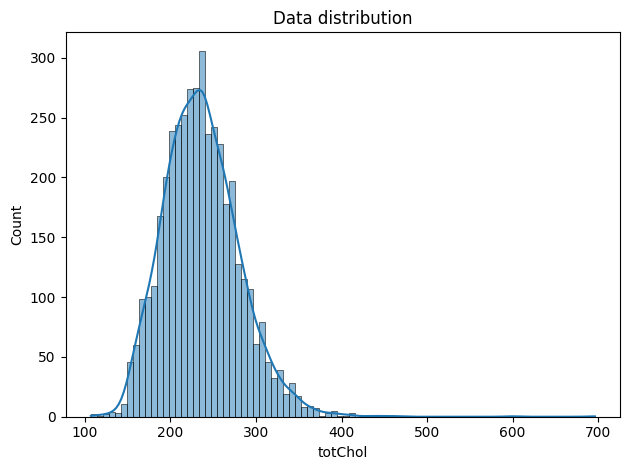

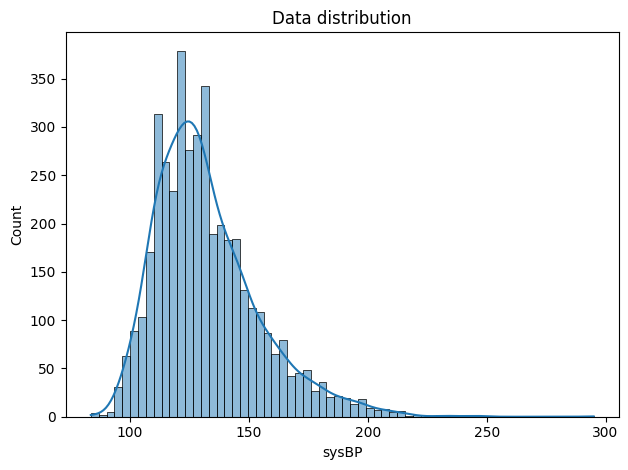

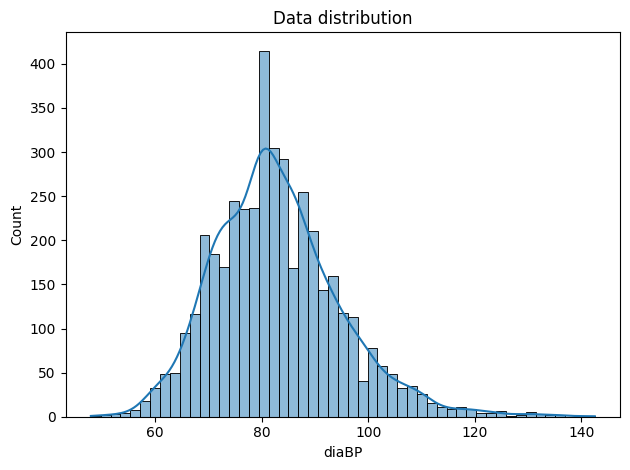

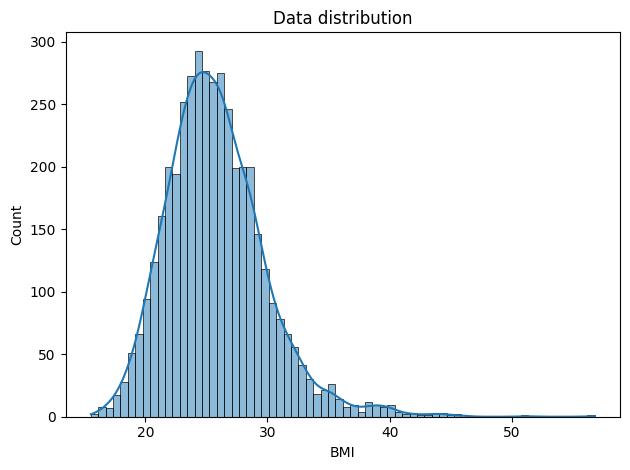

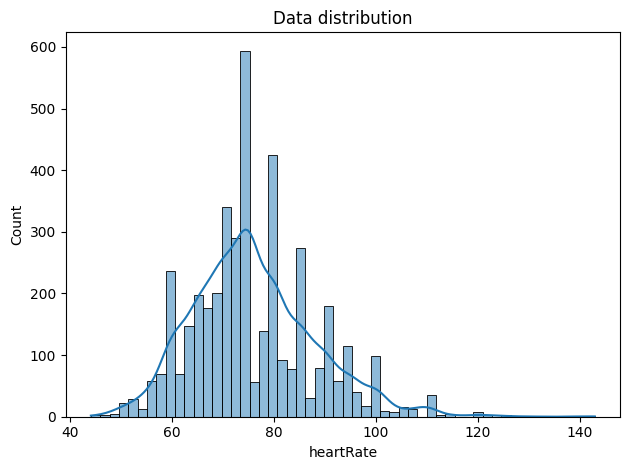

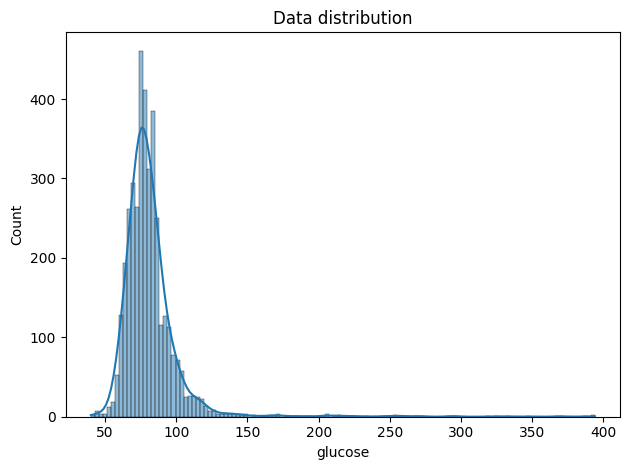

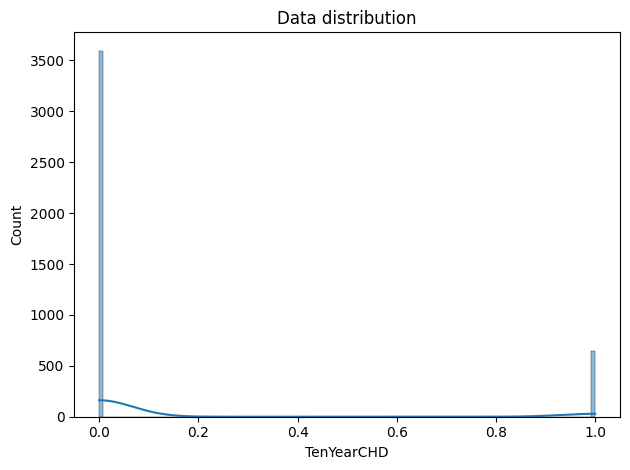

In [5]:
#Understand data distribution
data_col=df.columns
plt.Figure(figsize=(10,8))
for i,col in enumerate(data_col):
    sns.histplot(df[col],kde=True)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title('Data distribution')
    plt.tight_layout()
    plt.show()

In [6]:
#Hundling missing values
df.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [7]:
#prepare researve data
data=df.copy()

In [8]:
data[data_col]=data[data_col].fillna(data[data_col].mean(),axis=0)

In [9]:
data.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [10]:
#Ensure if thre any duplicate
data.duplicated().sum()

np.int64(0)

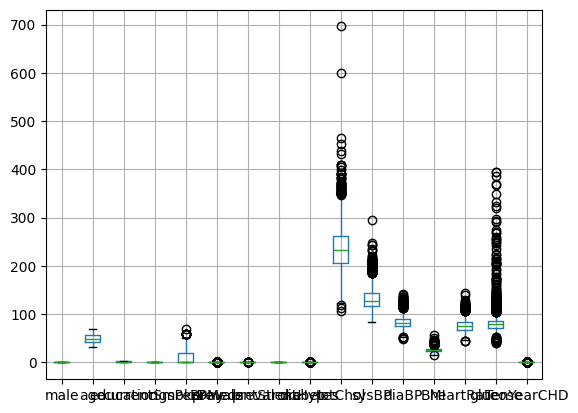

In [11]:
#Hundling outlayires
plt.Figure(figsize=(10,10))
data.boxplot()
plt.show()

In [12]:
#IQR technique
for col in data_col:
 Q1=np.percentile(data[col],25)
 Q3=np.percentile(data[col],75)
 IQR=Q3-Q1
 Upper_fence=1.5+Q3*IQR
 Lower_fence=1.5-Q1*IQR
 outlaiers=((data<Lower_fence)&(data>Upper_fence))



In [13]:
clean_data=data[~outlaiers]

In [14]:
print('Original data shape: ',data.shape)
print('Data shape after cleaning: ',clean_data.shape)

Original data shape:  (4240, 16)
Data shape after cleaning:  (4240, 16)


In [15]:
#Hundel outliers by ML IsolationForest algorithm
from sklearn.ensemble import IsolationForest
clf=IsolationForest().fit(data)
outlaier=clf.predict(data)

In [16]:
clean_data2=data.iloc[~outlaier]

In [17]:
clean_data2.shape #To ensure that IQR technique gives same result

(4240, 16)

In [18]:
#Build model of ML for CDH
#Load library
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix


In [19]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=1,max_depth=None)
models={
    'Logistic Regression':LogisticRegression(C=100,penalty='l2'),
    'Naive Bayes':GaussianNB(),
    'Randon Forest Classfier':RandomForestClassifier(n_estimators=20,random_state=12,max_depth=5),
    'K_Nearst Neighbors':KNeighborsClassifier(n_neighbors=10),
    'Decision Tree':DecisionTreeClassifier(criterion = 'entropy',random_state=0,max_depth = 6),
    'Support Vector Machine':SVC(kernel='rbf', C=2),
    'BaggingClassifier':BaggingClassifier(estimator=tree, n_estimators=500,max_samples=1.0,
                                          max_features=1.0,bootstrap=True,
                                          bootstrap_features=False,
                                          n_jobs=1, random_state=1)
}

In [20]:
#Split our data
x=clean_data.drop(columns='TenYearCHD',axis=1)
y=clean_data['TenYearCHD']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state = 20)

In [21]:
#understand our data structure
print(x.shape)
print(x_train.shape)
print(x_test.shape)
print()
print(y.shape)
print(y_train.shape)
print(y_test.shape)

(4240, 15)
(3392, 15)
(848, 15)

(4240,)
(3392,)
(848,)


In [22]:
#Scale data   
x_col=x_train.columns
X_train=pd.DataFrame(x_train,columns=x_col)  
 
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Model: Logistic Regression
Testing Accuracy:  0.839622641509434
Precision:  0.6470588235294118
Recall:  0.07801418439716312
F1 Score:  0.13924050632911392
Confusion Matrix:
  [[701   6]
 [130  11]]
Training set score: 0.858
Test set score: 0.840


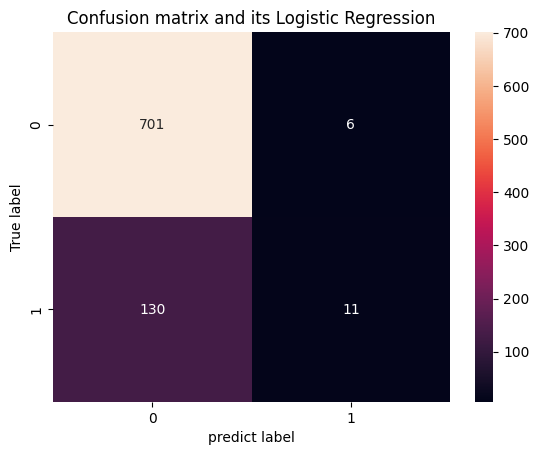



Model: Naive Bayes
Testing Accuracy:  0.8160377358490566
Precision:  0.4050632911392405
Recall:  0.22695035460992907
F1 Score:  0.2909090909090909
Confusion Matrix:
  [[660  47]
 [109  32]]
Training set score: 0.827
Test set score: 0.816


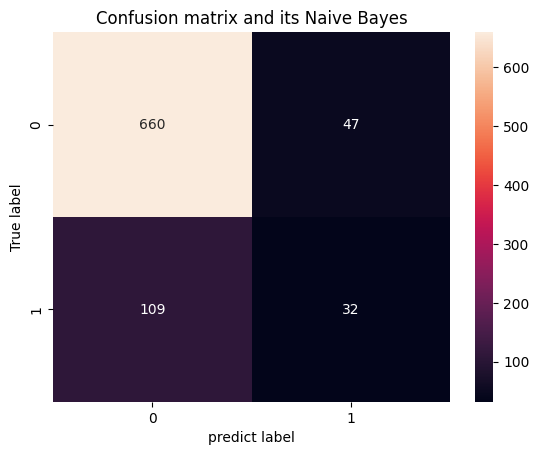



Model: Randon Forest Classfier
Testing Accuracy:  0.8360849056603774
Precision:  0.75
Recall:  0.02127659574468085
F1 Score:  0.041379310344827586
Confusion Matrix:
  [[706   1]
 [138   3]]
Training set score: 0.858
Test set score: 0.836


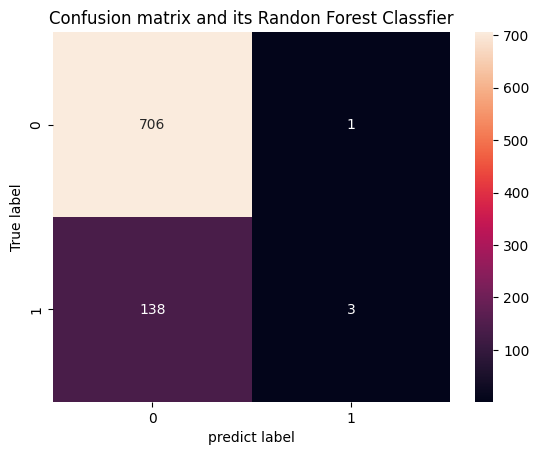



Model: K_Nearst Neighbors
Testing Accuracy:  0.8408018867924528
Precision:  0.8
Recall:  0.05673758865248227
F1 Score:  0.10596026490066225
Confusion Matrix:
  [[705   2]
 [133   8]]
Training set score: 0.857
Test set score: 0.841


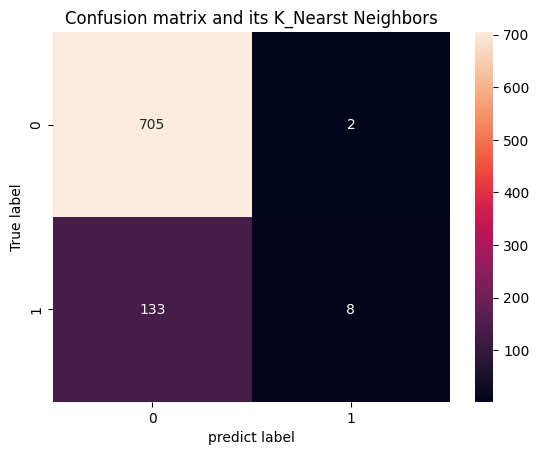



Model: Decision Tree
Testing Accuracy:  0.8325471698113207
Precision:  0.48148148148148145
Recall:  0.09219858156028368
F1 Score:  0.15476190476190477
Confusion Matrix:
  [[693  14]
 [128  13]]
Training set score: 0.874
Test set score: 0.833


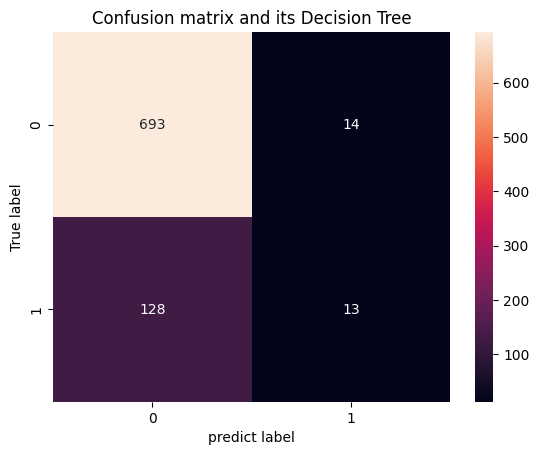



Model: Support Vector Machine
Testing Accuracy:  0.8408018867924528
Precision:  0.875
Recall:  0.04964539007092199
F1 Score:  0.09395973154362416
Confusion Matrix:
  [[706   1]
 [134   7]]
Training set score: 0.871
Test set score: 0.841


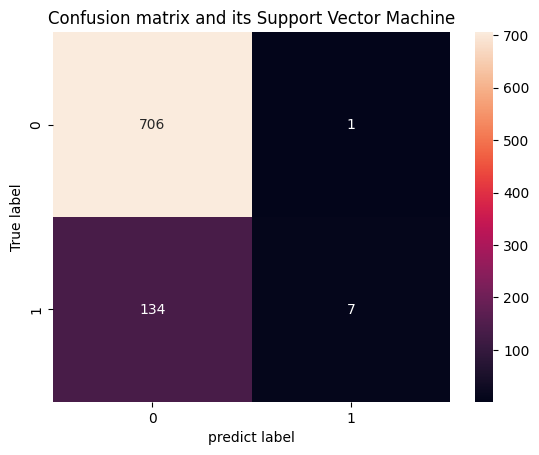



Model: BaggingClassifier
Testing Accuracy:  0.8337264150943396
Precision:  0.5
Recall:  0.06382978723404255
F1 Score:  0.11320754716981132
Confusion Matrix:
  [[698   9]
 [132   9]]
Training set score: 1.000
Test set score: 0.834


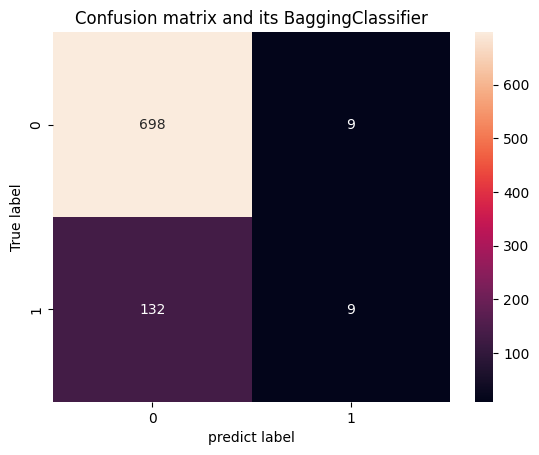

In [23]:
#Run our data in loop to predict and evaluate our data
model_list = []
accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
for model_name, model in models.items():

    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred = model.predict(x_test)
    
    # Evaluate the model
    #train_accuracy = accuracy_score(x_train,y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    confusion_mat = confusion_matrix(y_test, y_pred)

    print(f"Model: {model_name}")
    print("Testing Accuracy: ", test_accuracy)
    print("Precision: ",precision)
    print("Recall: ",recall)
    print("F1 Score: ",f1)
    print("Confusion Matrix:\n ",confusion_mat)
    print("Training set score: {:.3f}".format(model.score(x_train, y_train)))
    print("Test set score: {:.3f}".format(model.score(x_test, y_test)))

    model_list.append(model_name)
    accuracy_list.append(test_accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
     
    cm=confusion_mat
    sns.heatmap(cm,annot=True,fmt='d')
    plt.title(f"Confusion matrix and its {model_name}")
    plt.ylabel("True label")
    plt.xlabel("predict label")
    plt.show()

    print("=" * 35)
    print('\n')

In [24]:
max_accuracy_index = accuracy_list.index(max(accuracy_list))
print(f"The best model based on accuracy is {model_list[max_accuracy_index]} with Testing Accuracy: {accuracy_list[max_accuracy_index]}")


The best model based on accuracy is K_Nearst Neighbors with Testing Accuracy: 0.8408018867924528


In [25]:
#Aplly PCA
pca = PCA(n_components=2)  
lr=LogisticRegression(multi_class='ovr',random_state=1,solver='lbfgs')
X_train_pca = pca.fit_transform(x_train)
X_test_pca = pca.transform(x_test)
lr.fit(X_train_pca,y_train)

c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [26]:
print(f"Original shape: {x_train.shape}")
print(f"Reduced shape: {X_train_pca.shape}")
print(f"Explained variance: {sum(pca.explained_variance_ratio_):.3f}")

Original shape: (3392, 15)
Reduced shape: (3392, 2)
Explained variance: 0.340


In [27]:
from matplotlib.colors import ListedColormap
def plot_decision_region(X,y,classifier,resolution=0.02):
    #set up marker and colors map
    markers=('s','x','o','^','v')
    colors=('red','blue','lightgreen','gray')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    #plot decision surface
    X1_min,X1_max=X[:,0].min()-1,X[:,0].max()+1
    X2_min,X2_max=X[:,1].min()-1,X[:,1].max()+1
    XX1,XX2=np.meshgrid(np.arange(X1_min,X1_max,resolution),
    np.arange(X2_min,X2_max,resolution))
    Z = classifier.predict(np.array([XX1.ravel(), XX2.ravel()]).T)
    Z = Z.reshape(XX1.shape)
    plt.contourf(XX1, XX2, Z, alpha=0.3, cmap=cmap)    
    plt.xlim(XX1.min(),XX1.max())
    plt.ylim(XX2.min(),XX2.max())
    #plot class example
    for idx,col in enumerate(np.unique(y)):
        sns.scatterplot(x=X[y==col,0],y=X[y==col,1],alpha=0.8,label=col,marker=markers[idx], edgecolor='black')


In [28]:
cov_mat=np.cov(x_train.T)
eig_vals,eig_vecs=np.linalg.eig(cov_mat)
tot=sum(eig_vals)
print(tot)

15.004423473901507


In [29]:
# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eig_vals[i]), eig_vecs[:, i]) 
                for i in range(len(eig_vals))]
# Sort the (eigenvalue, eigenvector) tuples from high to low
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

In [30]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis], 
                eigen_pairs[1][1][:, np.newaxis]))
print('Matrix W:\n', w)

Matrix W:
 [[ 0.05226616 -0.35748372]
 [-0.29439749  0.1059732 ]
 [ 0.10776453  0.02416399]
 [ 0.21402933 -0.57068193]
 [ 0.18209767 -0.61688887]
 [-0.19859737 -0.04903821]
 [-0.06274493  0.01527955]
 [-0.43059388 -0.17958315]
 [-0.13645232  0.0620853 ]
 [-0.17994352 -0.01086242]
 [-0.48318815 -0.16703411]
 [-0.43238255 -0.2254988 ]
 [-0.28429102 -0.05445303]
 [-0.12177748 -0.16671159]
 [-0.15541112  0.07610869]]


In [31]:
X_train_pca = x_train.dot(w)

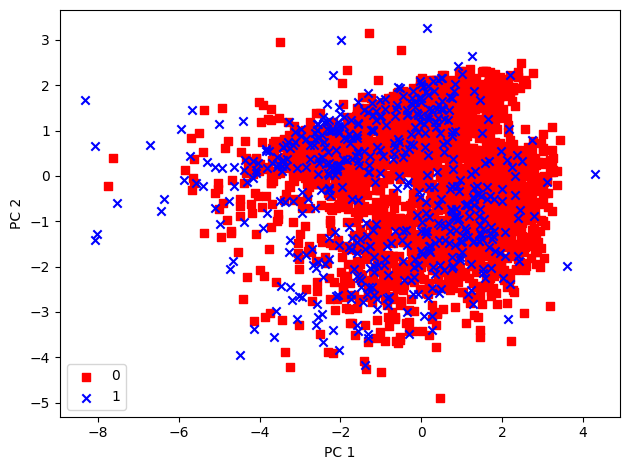

In [32]:
colors = ['r', 'b', 'g']
markers = ['s', 'x', 'o']
for l, c, m in zip(np.unique(y_train), colors, markers):
     plt.scatter(X_train_pca[y_train==l, 0], 
                 X_train_pca[y_train==l, 1], 
                 c=c, label=l, marker=m)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

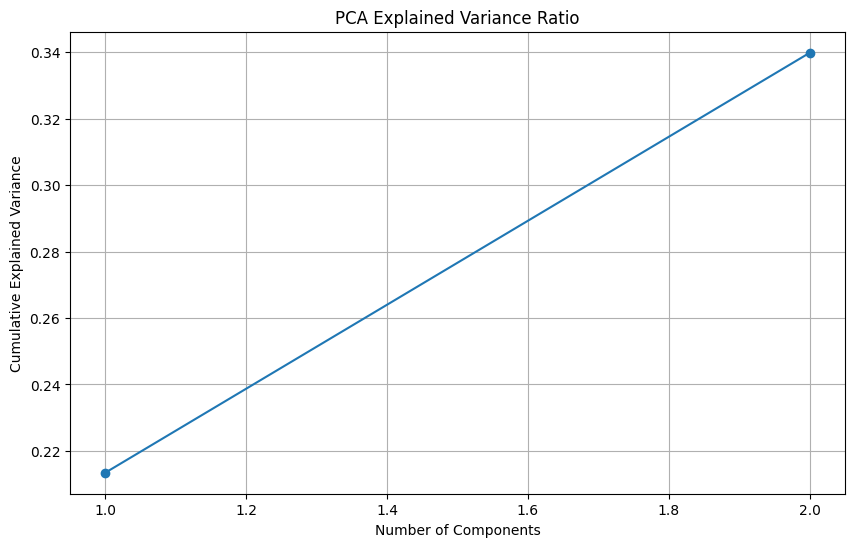

In [33]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Ratio')
plt.grid(True)
plt.show()

c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\utils.py:105: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scout = method(scout_x, scout_y, **kws)
c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\relational.py:438: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)


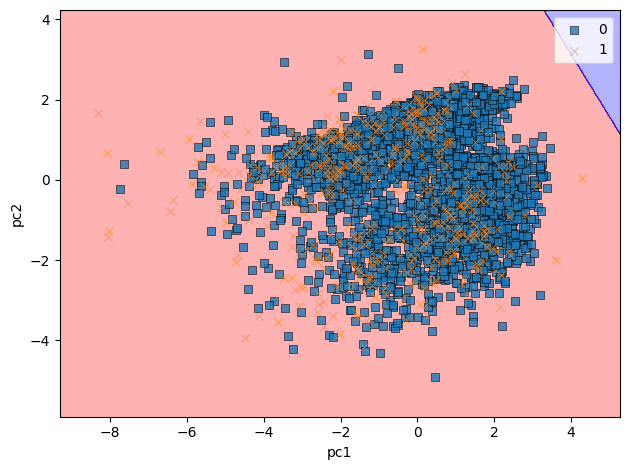

In [34]:
plot_decision_region(X_train_pca,y_train,classifier=lr)
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()
plt.legend(loc='best')
plt.show()

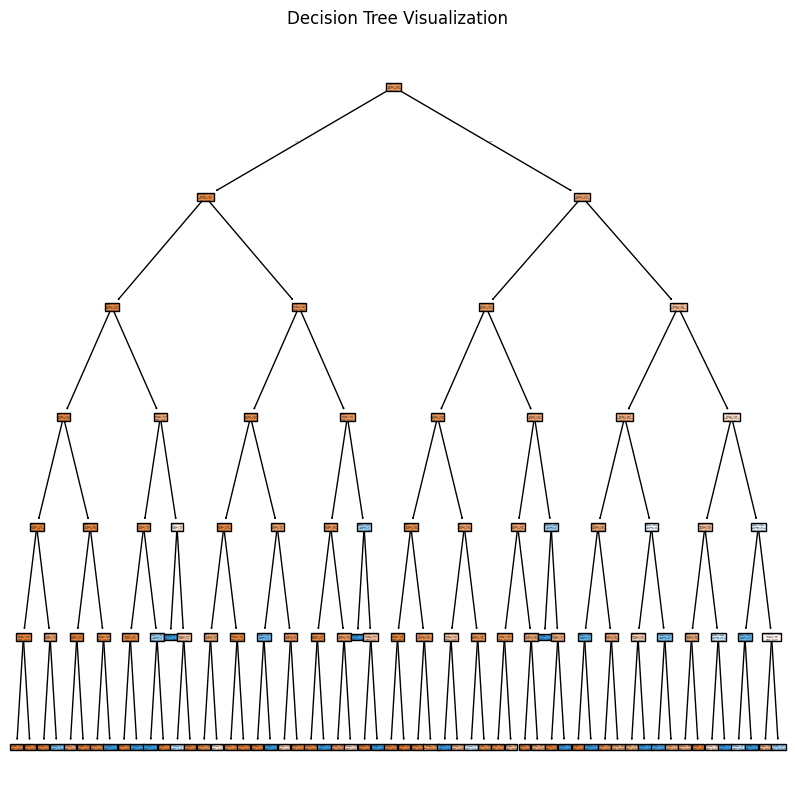

In [35]:
#descision tree plot
plt.figure(figsize=(10,10))
plot_tree(models['Decision Tree'], filled=True, feature_names=df.columns[:-1], class_names=['Normal', 'Abnormal'])
plt.title('Decision Tree Visualization')
plt.show()


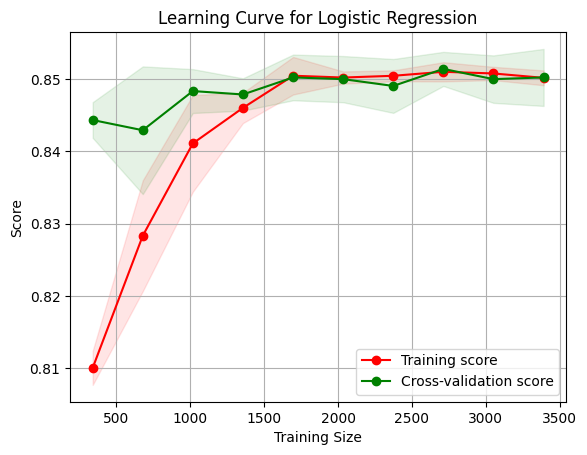

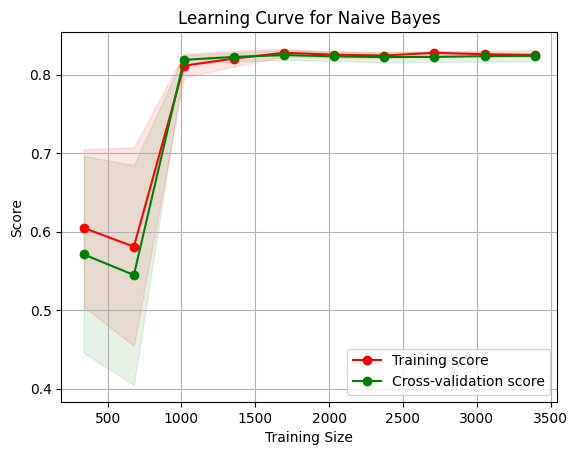

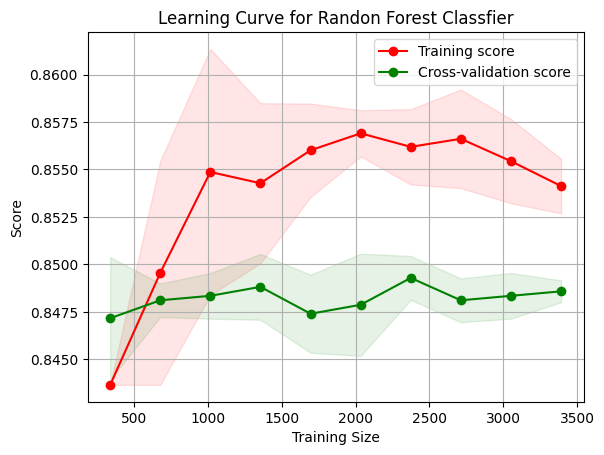

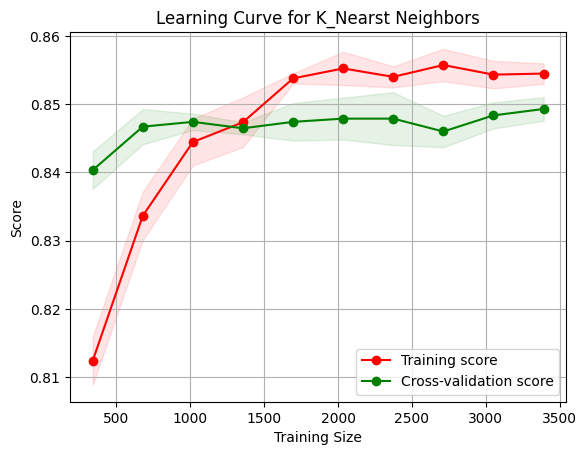

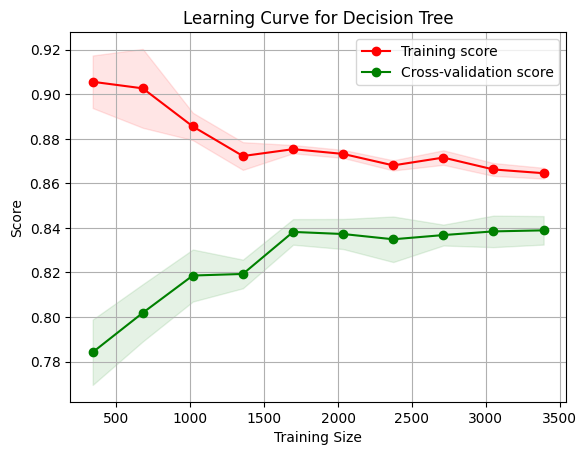

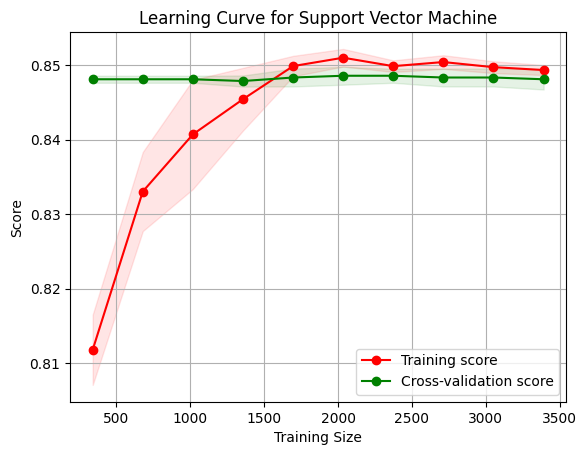

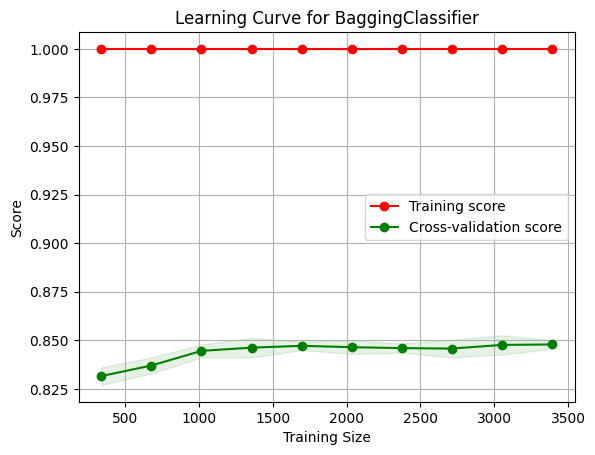

In [36]:
#Learning curve plots
from sklearn.model_selection import learning_curve

for model_name,model in models.items():
    train_sizes, train_scores, test_scores = learning_curve(model, x, y, cv=5, n_jobs=-1, 
                                                            train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    train_scores_std=np.std(train_scores, axis=1)
    test_scores_std=np.std(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
    plt.fill_between(train_sizes, train_scores_mean-train_scores_std,
                    train_scores_mean+train_scores_std,alpha=0.1,color='r')
    plt.fill_between(train_sizes, test_scores_mean-test_scores_std,
                    test_scores_mean+test_scores_std,alpha=0.1,color='g')
    plt.title(f'Learning Curve for {model_name}')
    plt.xlabel('Training Size')
    plt.ylabel('Score')
    plt.legend(loc='best')
    plt.grid()
    plt.show()

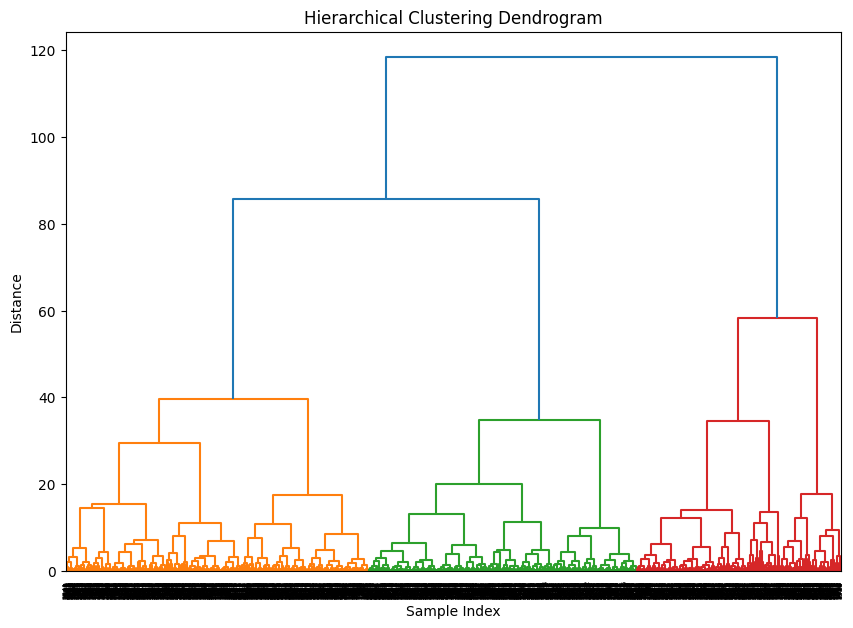

In [37]:
#hirearchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_train_pca, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')        
plt.ylabel('Distance')
plt.show()

In [38]:
#Prepare pipeline for our model
from sklearn.pipeline import Pipeline
Pipelin=Pipeline([
    ('Scaler',StandardScaler()),
    ('PCA',PCA(n_components=2)),
    ('Support Vector Machine',SVC(kernel='rbf', C=2))
])

In [39]:
#Evaluate pipeline model
Pipelin.fit(x_train,y_train)
score=Pipelin.score(x_test,y_test)
print('Pipeline score', score)

Pipeline score 0.8349056603773585


In [40]:
#prepare MajorityVotingClassifier
from sklearn.model_selection import cross_val_score

clf1 = LogisticRegression(penalty='l2',C=0.001,solver='lbfgs',random_state=1)
clf2 = DecisionTreeClassifier(max_depth=1, criterion='entropy', random_state=0)
clf3 = KNeighborsClassifier(n_neighbors=1, p=2,metric='minkowski')
pipe1 = Pipeline([['sc', StandardScaler()], ['clf', clf1]])
pipe3 = Pipeline([['sc', StandardScaler()],['clf', clf3]])
clf_labels = ['Logistic regression', 'Decision tree', 'KNN']
print('10-fold cross validation:\n')
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
 scores = cross_val_score(estimator=clf,
 X=X_train,
 y=y_train,
 cv=10,
 scoring='roc_auc')
 print("ROC AUC: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))

10-fold cross validation:

ROC AUC: 0.72 (+/- 0.03) [Logistic regression]
ROC AUC: 0.63 (+/- 0.04) [Decision tree]
ROC AUC: 0.54 (+/- 0.03) [KNN]


In [41]:
#Build mvc model
import operator
from sklearn.base import BaseEstimator, ClassifierMixin,clone
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import _name_estimators

class MajorityVoteClassifier(BaseEstimator,ClassifierMixin):
    """ A majority vote ensemble classifier
 
 Parameters
 ----------
 classifiers : array-like, shape = [n_classifiers]
 Different classifiers for the ensemble
 
 vote : str, {'classlabel', 'probability'}
 Default: 'classlabel'
 If 'classlabel' the prediction is based on
 the argmax of class labels. Else if
 'probability', the argmax of the sum of
 probabilities is used to predict the class label
 (recommended for calibrated classifiers).
 
 weights : array-like, shape = [n_classifiers]
 Optional, default: None
 If a list of 'int' or 'float' values are
 provided, the classifiers are weighted by
 importance; Uses uniform weights if 'weights=None'.
 
 """
    def __init__(self,classifiers,vote='classlabel',weights=None):
        self.classifiers = classifiers
        self.named_classifiers = {key:value for key,value in _name_estimators(classifiers)}        
        self.vote = vote
        self.weights = weights

    def fit(self,X,y):
      """ Fit classifiers.
 
        Parameters
        ----------
      X : {array-like, sparse matrix},
      shape = [n_examples, n_features]
      Matrix of training examples.
 
     y : array-like, shape = [n_examples]
     Vector of target class labels.
 
     Returns
     -------
     self : object
 
     """
      if self.vote not in('probability','classlabel'):
         raise ValueError("vote must be 'probability'" "or 'classlabel'; got (vote=%r)"% self.vote)
      
      if self.weights and len(self.weights) !=len(self.classifiers):
         raise ValueError("Number of classifiers and weights"
                         "must be equal; got %d weights,"
                          "%d classifiers"
                          % (len(self.weights),
                          len(self.classifiers)))
      
      # Use LabelEncoder to ensure class labels start
      # with 0, which is important for np.argmax
      # call in self.predict
      self.lablenc_ = LabelEncoder()
      self.lablenc_.fit(y)
      self.classes_=self.lablenc_.classes_
      self.classifiers_=[]
      for clf in self.classifiers:
         fitted_clf=clone(clf).fit(X,self.lablenc_.transform(y))
         self.classifiers_.append(fitted_clf)
         return self
    def predict(self, X):
        """ Predict class labels for X.
 
        Parameters
        ----------
        X : {array-like, sparse matrix},
        Shape = [n_examples, n_features]
        Matrix of training examples.
 
        Returns
        ----------
        maj_vote : array-like, shape = [n_examples]
        Predicted class labels.
 
        """
        if self.vote == 'probability':
          maj_vote=np.argmax(self.predict_proba(X),axis=1)
        else:  
         #collect result from clf.predoct calss
         predictions = np.asarray([clf.predict for clf in self.classifiers_]).T
         maj_vote = np.apply_along_axis(lambda x: np.argmax(np.bincount(x,weights=self.weights)),
                                            axis=1, arr=predictions)
         maj_vote = self.lablenc_.inverse_transform(maj_vote)
         return maj_vote
    def predict_proba(self, X):
        """ Predict class probabilities for X.
 
         Parameters
         ----------
        X : {array-like, sparse matrix}, shape = [n_examples, n_features]Training vectors, where
        n_examples is the number of examples and n_features is the number of features.
 
         Returns
        ----------
        avg_proba : array-like,
        shape = [n_examples, n_classes]
        Weighted average probability for
        each class per example.
 
        """
        probas = np.asarray([clf.predict_proba(X)for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0,weights=self.weights)
        return avg_proba
    def get_params(self,deep=True):
       if not deep:
          return super(MajorityVoteClassifier,self).get_params(deep=False)
       else:
          out=self.named_classifiers.copy()
          for name,stop in self.named_classifiers.items():
             for key,val in stop.get_params(deep=True):
                out['%s__%s' % (name, key)]= value
             return out       

                
    

In [42]:
mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3])
clf_labels += ['Majority voting']
all_clf = [pipe1, clf2, pipe3, mv_clf]
for clf, label in zip(all_clf, clf_labels):
 scores = cross_val_score(estimator=clf, X=X_train,y=y_train,cv=10,scoring='roc_auc')
print("ROC AUC: %0.2f (+/- %0.2f) [%s]"% (scores.mean(), scores.std(), label))

c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 152, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 400, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ~~~~~~~~~~~~~~~~~~~~^
        estimator, *args, response_method=response

ROC AUC: nan (+/- nan) [Majority voting]


c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\rafaa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


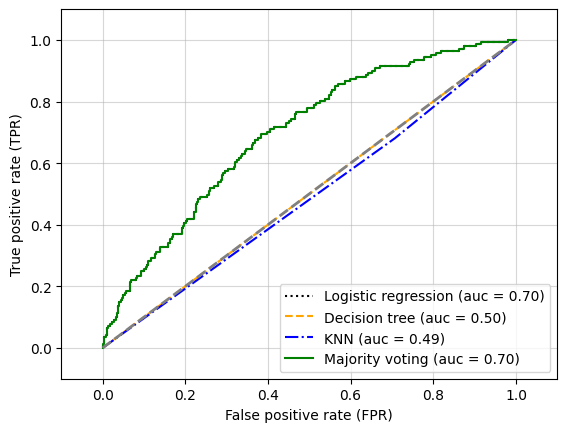

In [43]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
colors = ['black', 'orange', 'blue', 'green']
linestyles = [':', '--', '-.', '-']
for clf, label, clr, ls in zip(all_clf, clf_labels, colors, linestyles):
 # assuming the label of the positive class is 1
    y_pred = clf.fit(X_train, y_train).predict_proba(x_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test,y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr,color=clr,linestyle=ls,label='%s (auc = %0.2f)' % (label, roc_auc))

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1],linestyle='--',color='gray',linewidth=2)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (TPR)')
plt.show()



